In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:

# AD SPIN UP
# V5
#fates_ad = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_AD_spinup_v5.Ea435e8dd8c-Fea425ee7.2025-05-13/run/PA_AD_spinup_v5.Ea435e8dd8c-Fea425ee7.2025-05-13.sofar.nc'
fates_ad = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_AD_spinup_v6_v12.Ea8fbc2fc28-Ff46de7a5.2025-06-16/run/PA_AD_spinup_v6_v12.Ea8fbc2fc28-Ff46de7a5.2025-06-16.sofar.nc'
fates_ad = xr.open_dataset(fates_ad)

# POST AD SPINUP
#fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_post_AD_spinup_v5.Ea435e8dd8c-Fea425ee7.2025-05-14/run/PA_post_AD_spinup_v5.Ea435e8dd8c-Fea425ee7.2025-05-14.sofar.nc'
fates = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_post_AD_spinup.Ea8fbc2fc28-Ff46de7a5.2025-06-16/run/PA_post_AD_spinup.Ea8fbc2fc28-Ff46de7a5.2025-06-16.sofar.nc'
fates = xr.open_dataset(fates)

In [3]:
fates = xr.concat((fates_ad, fates), dim='time')

In [4]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = np.arange(0,len(fates.variables['time']),1)/12

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
#print(cohort_size_bins)
print(nsizebins)
patch_age_bins = fates.variables['fates_levage'][:]

decomp_bins = fates.variables['levdcmp']

500
17


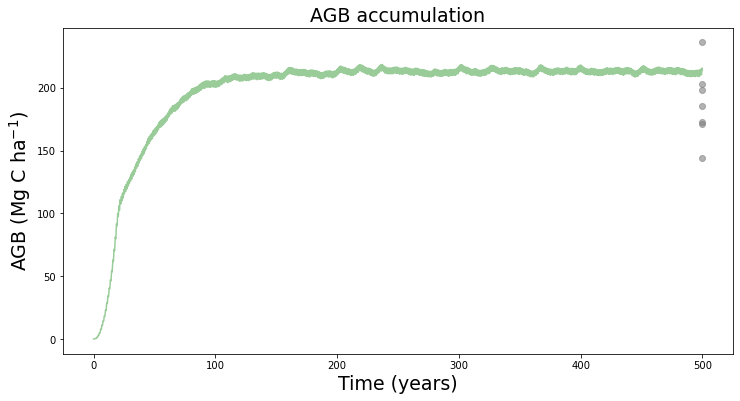

In [5]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    

gedi_x = [500,500,500,500,500,500,500]
gedi_y = [171.59, 172.45, 185.59, 143.95, 203.19, 198.31, 236.16] # Mg ha-1 - aboveground biomass density 

f1ax0.scatter(gedi_x, gedi_y, alpha=0.6, color='grey')

Text(0, 0.5, 'Vegc (kg C m-2)')

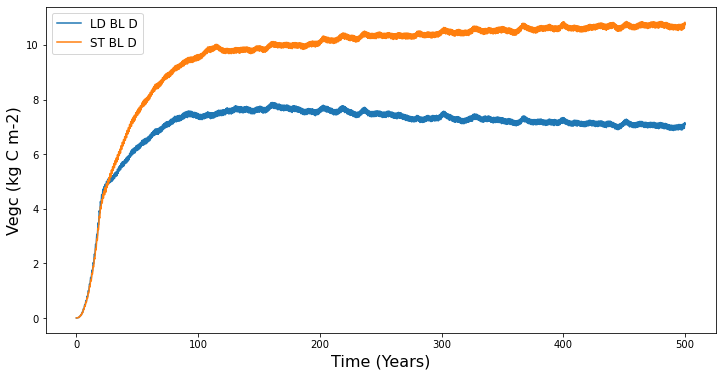

In [6]:
AGB = fates.FATES_VEGC_PF

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(12,6))
axs.plot(time, AGB.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, AGB.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

axs.set_xlabel(r'Time (Years)', fontsize=16)
axs.set_ylabel(r'Vegc (kg C m-2)', fontsize=16)

Text(0.5, 1.0, 'Veg C by Patch Age x PFT')

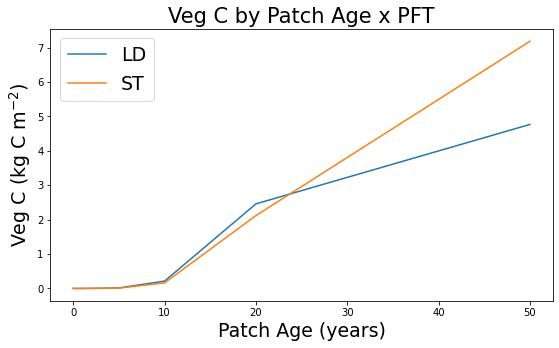

In [7]:
vegc_appf  = fa.appf_to_ap_by_pft(fates.FATES_VEGC_APPF, fates)
vegc_appf  = np.squeeze(vegc_appf.isel(time=slice(1080,1200)).mean(dim='time'))

# set up the page
fig3, ((f3ax0)) = plt.subplots(nrows=1, ncols=1, figsize=(9, 5))

f3ax0.plot(patch_age_bins, vegc_appf.isel(fates_levpft=0),  label = 'LD')
f3ax0.plot(patch_age_bins, vegc_appf.isel(fates_levpft=1),  label = 'ST')
f3ax0.legend(fontsize=19)
f3ax0.set_xlabel('Patch Age (years)', fontsize=19)
f3ax0.set_ylabel(r'Veg C (kg C m$^{-2}$)', fontsize=19)
f3ax0.set_title('Veg C by Patch Age x PFT', fontsize=21)



In [8]:
fates_best = fates

(0.0, 80.0)

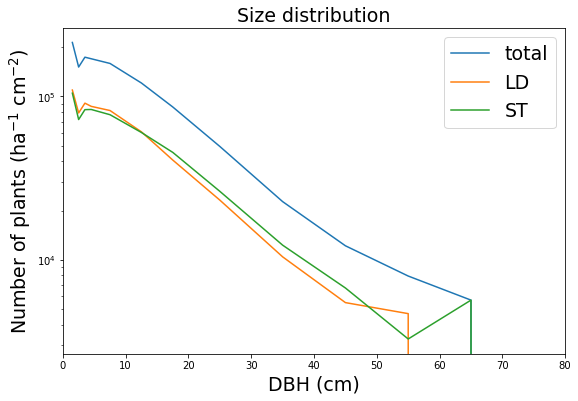

In [12]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

nplant = NPLANT_SZ.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000 # convert to plants per ha (from m-2)
nplant = np.squeeze(nplant)
fates_sd = np.squeeze(nplant[1:,])/fates_sizebin_widths

nplant1 = NPLANT_SZPF.isel(fates_levpft=0)
nplant2 = NPLANT_SZPF.isel(fates_levpft=1)

nplant1 = nplant1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant2 = nplant2.isel(time=slice(tave_start,tave_stop)).mean(dim='time') * 10000
nplant1 = np.squeeze(nplant1)
nplant2 = np.squeeze(nplant2)

fates_sd1 = np.squeeze(nplant1[1:,])/fates_sizebin_widths
fates_sd2 = np.squeeze(nplant2[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(9,6))

f2ax0.plot(fates_sizebin_mids, fates_sd,  label = 'total')
f2ax0.plot(fates_sizebin_mids, fates_sd1,  label = 'LD')
f2ax0.plot(fates_sizebin_mids, fates_sd2,  label = 'ST')
    
f2ax0.set_title(r'Size distribution', fontsize = 19)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 19)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 19)    

f2ax0.legend(fontsize=19)
f2ax0.set_yscale('log')
#f2ax0.set_xscale('log')
f2ax0.set_xlim(0,80)

### Compare the forest at 120 years to the SERC data from Piponiot et al data

In [13]:
pip_data = pd.read_csv('/global/homes/j/jneedham/plot_data/Piponiot_2022_NewPhyt_AGB_AWP_AWM_standard_size_class.csv')
serc = pip_data['site'] == 'SERC'
serc_data = pip_data[serc]
serc_data_agb = serc_data[serc_data['variable'] == 'AGB']
serc_data_agb

,site,variable,size_class,total,lower_bound,upper_bound
435,SERC,AGB,"[1,5)",1.218,1.110,1.329
436,SERC,AGB,"[5,10)",2.552,2.342,2.765
437,SERC,AGB,"[10,20)",7.663,6.976,8.395
438,SERC,AGB,"[20,30)",14.225,12.790,15.670
439,SERC,AGB,"[30,40)",25.423,22.542,28.535
440,SERC,AGB,"[40,50)",34.570,29.979,39.270
441,SERC,AGB,"[50,100)",171.022,154.802,186.948
442,SERC,AGB,"[100,200)",16.575,8.451,25.329


In [14]:
print(cohort_size_bins_ex)

[  1.   2.   3.   4.   5.  10.  15.  20.  30.  40.  50.  60.  70.  80.
  90. 100. 250.]


<xarray.DataArray 'FATES_VEGC_ABOVEGROUND_SZ' (fates_levscls: 16)>
array([6.3554440e-03, 1.3511142e-02, 3.8812496e-02, 5.7033248e-02,
       1.3494056e+00, 3.8680222e+00, 6.7787790e+00, 1.8010826e+01,
       2.1516470e+01, 2.2516216e+01, 1.1349396e+01, 1.8655190e+01,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
      dtype=float32)
Coordinates:
  * fates_levscls  (fates_levscls) float32 1.0 2.0 3.0 4.0 ... 80.0 90.0 100.0


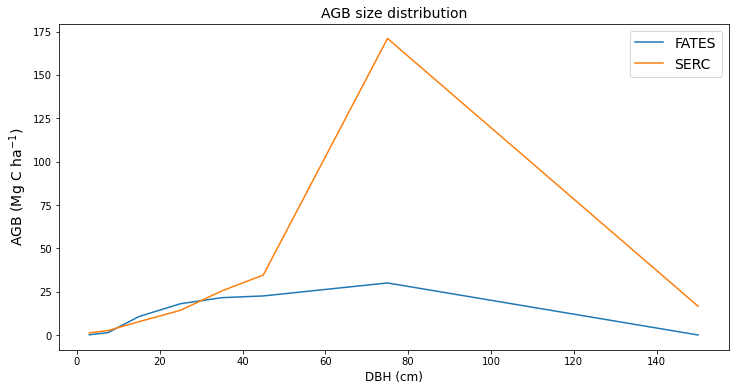

In [15]:
AGB_SZ = fates_best.FATES_VEGC_ABOVEGROUND_SZ * 10000 # m2 to ha

agb = AGB_SZ.sel(time=slice('0119-01-01','0120-01-01')).mean(dim='time') * 0.001  # kg to Mg
agb = np.squeeze(agb)

# remove the first size bin
fates_agb = np.squeeze(agb[1:,])
print(fates_agb)
# combine the 1-5 bins into a single bin
fates_agb = fates_agb.groupby_bins('fates_levscls', bins=np.array([1,5,10,20,30,40,50,100,200]), right=False).sum()

sizebin_mids = np.array([3, 7.5, 15, 25, 35, 45, 75, 150])

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(sizebin_mids, fates_agb,  label = 'FATES')
f2ax0.plot(sizebin_mids, serc_data_agb['total'], label='SERC')

f2ax0.set_title(r'AGB size distribution', fontsize = 14)
f2ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 14)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend(fontsize=14)
# f2ax0.set_yscale('log')
# #f2ax0.set_xscale('log')

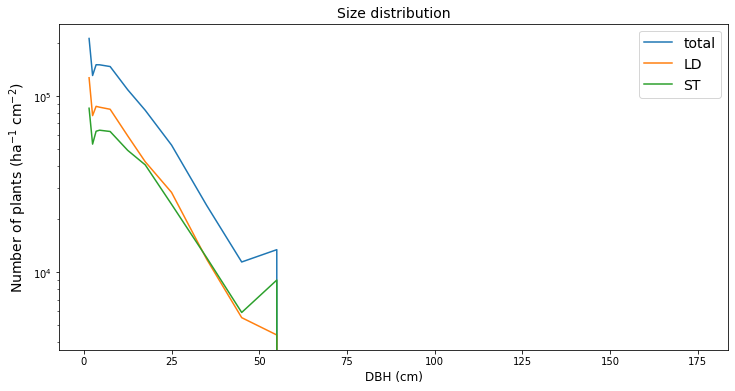

In [16]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

nplant = NPLANT_SZ.isel(time=slice(1200,1320)).mean(dim='time') * 10000 # convert to plants per ha (from m-2)
nplant = np.squeeze(nplant)
fates_sd = np.squeeze(nplant[1:,])/fates_sizebin_widths

nplant1 = NPLANT_SZPF.isel(fates_levpft=0)
nplant2 = NPLANT_SZPF.isel(fates_levpft=1)

nplant1 = nplant1.isel(time=slice(1200,1320)).mean(dim='time') * 10000
nplant2 = nplant2.isel(time=slice(1200,1320)).mean(dim='time') * 10000
nplant1 = np.squeeze(nplant1)
nplant2 = np.squeeze(nplant2)

fates_sd1 = np.squeeze(nplant1[1:,])/fates_sizebin_widths
fates_sd2 = np.squeeze(nplant2[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, fates_sd,  label = 'total')
f2ax0.plot(fates_sizebin_mids, fates_sd1,  label = 'LD')
f2ax0.plot(fates_sizebin_mids, fates_sd2,  label = 'ST')
    
f2ax0.set_title(r'Size distribution', fontsize = 14)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 14)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend(fontsize=14)
f2ax0.set_yscale('log')
#f2ax0.set_xscale('log')

(6000, 1, 17)


Text(0, 0.5, 'Cohort Size (cm)')

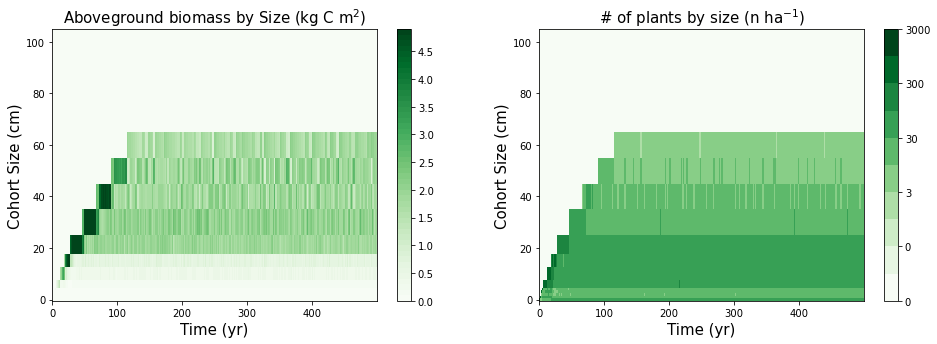

In [17]:
# population numbers as a function of cohort size
NPLANT_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) * 10000
NPLANT_SZ =  NPLANT_SZPF.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_VEGC_ABOVEGROUND_SZPF, fates_best)
VEGC_ABOVEGROUND_SZ  = VEGC_ABOVEGROUND_SZPF.sum(dim='fates_levpft')
print(VEGC_ABOVEGROUND_SZ.shape)

fig2, ((f2ax0, f2ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(16,5))

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax0.pcolormesh(time, cohort_size_bins, VEGC_ABOVEGROUND_SZ[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'Aboveground biomass by Size (kg C m$^2$)', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax1.pcolormesh(time, cohort_size_bins, (NPLANT_SZ)[:,0,:].transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'# of plants by size (n ha$^{-1}$)', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)

### Growth and mortality 

In [18]:
dark = cm.get_cmap('Paired', 12)
colormap = dark(range(12))

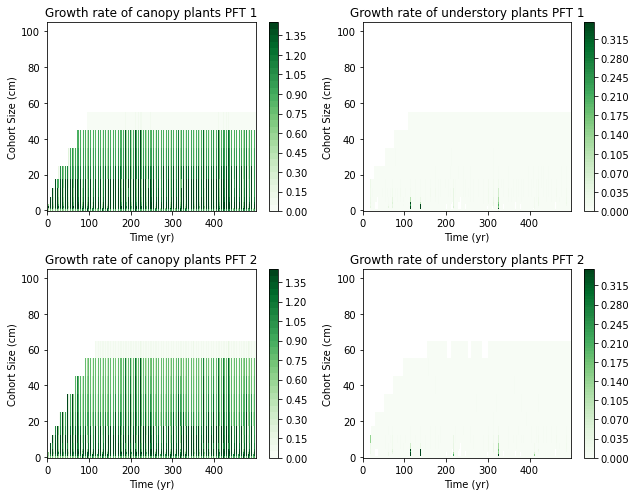

In [22]:
NPLANT_CANOPY_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_CANOPY_SZPF, fates_best) 
NPLANT_USTORY_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_NPLANT_USTORY_SZPF, fates_best)

DDBH_CANOPY_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_DDBH_CANOPY_SZPF, fates_best) * 100 # convert to cm
DDBH_USTORY_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_DDBH_USTORY_SZPF, fates_best) * 100 # convert to cm

MORT_CANOPY_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_MORTALITY_CANOPY_SZPF, fates_best)
MORT_USTORY_SZPF = fa.scpf_to_scls_by_pft(fates_best.FATES_MORTALITY_USTORY_SZPF, fates_best)

# set up the page
fig3, ((f3ax0, f3ax1), (f3ax2, f3ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,1.5, 0.05)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_CANOPY_SZPF.isel(fates_levpft=0) / NPLANT_CANOPY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Growth rate of canopy plants PFT 1')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.35, 0.005)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_USTORY_SZPF.isel(fates_levpft=0) / NPLANT_USTORY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'Growth rate of understory plants PFT 1')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

levels = np.arange(0.,1.5, 0.05)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_CANOPY_SZPF.isel(fates_levpft=1) / NPLANT_CANOPY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Growth rate of canopy plants PFT 2')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,0.35, 0.005)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(DDBH_USTORY_SZPF.isel(fates_levpft=1) / NPLANT_USTORY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Growth rate of understory plants PFT 2')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

fig3.tight_layout()

In [23]:
NPLANT_CANOPY_SZPF = fa.scpf_to_scls_by_pft(fates.FATES_NPLANT_CANOPY_SZPF, fates) 
NPLANT_USTORY_SZPF = fa.scpf_to_scls_by_pft(fates.FATES_NPLANT_USTORY_SZPF, fates)

DDBH_CANOPY_SZPF = fa.scpf_to_scls_by_pft(fates.FATES_DDBH_CANOPY_SZPF, fates) * 100 # convert to cm
DDBH_USTORY_SZPF = fa.scpf_to_scls_by_pft(fates.FATES_DDBH_USTORY_SZPF, fates) * 100 # convert to cm

DDBH_CANOPY = DDBH_CANOPY_SZPF.sum(dim='fates_levscls')/NPLANT_CANOPY_SZPF.sum(dim='fates_levscls')
DDBH_CANOPY = DDBH_CANOPY.sel(time=slice("0390-01-01", "0400-01-01")).mean(dim='time')
print(DDBH_CANOPY)

DDBH_USTORY = DDBH_USTORY_SZPF.sum(dim='fates_levscls')/NPLANT_USTORY_SZPF.sum(dim='fates_levscls')
DDBH_USTORY = DDBH_USTORY.sel(time=slice("0390-01-01", "0400-01-01")).mean(dim='time')
print(DDBH_USTORY)

<xarray.DataArray (fates_levpft: 2, lndgrid: 1)>
array([[0.7081955 ],
       [0.64600813]], dtype=float32)
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2
Dimensions without coordinates: lndgrid
<xarray.DataArray (fates_levpft: 2, lndgrid: 1)>
array([[0.00075447],
       [0.00065607]], dtype=float32)
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2
Dimensions without coordinates: lndgrid


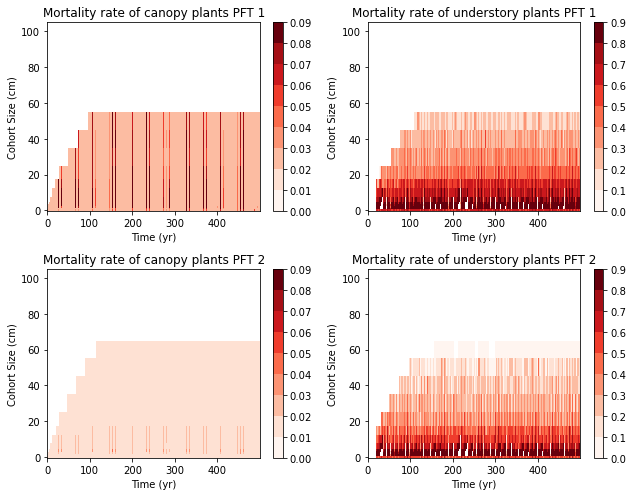

In [24]:
# set up the page
fig3, ((f3ax0, f3ax1), (f3ax2, f3ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_CANOPY_SZPF.isel(fates_levpft=0) / NPLANT_CANOPY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Mortality rate of canopy plants PFT 1')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,1.0, 0.1)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_USTORY_SZPF.isel(fates_levpft=0) / NPLANT_USTORY_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'Mortality rate of understory plants PFT 1')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_CANOPY_SZPF.isel(fates_levpft=1) / NPLANT_CANOPY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Mortality rate of canopy plants PFT 2')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')

## set up the second plot: growth rate in the understory, units as above
levels = np.arange(0.,1.0, 0.1)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_USTORY_SZPF.isel(fates_levpft=1) / NPLANT_USTORY_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Mortality rate of understory plants PFT 2')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

fig3.tight_layout()

In [25]:
MORT_B_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_BACKGROUND_SZPF, fates_best)
MORT_C_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_CSTARV_SZPF, fates_best)
MORT_T_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_TERMINATION_SZPF, fates_best)
MORT_I_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_IMPACT_SZPF, fates_best)
MORT_H_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_HYDRAULIC_SZPF, fates_best)
MORT_F_SZPF = szpf_to_scls_by_pft(fates_best.FATES_MORTALITY_FREEZING_SZPF, fates_best)
NPLANT_SZPF = szpf_to_scls_by_pft(fates_best.FATES_NPLANT_SZPF, fates_best) 

NameError: name 'szpf_to_scls_by_pft' is not defined

In [ ]:
# set up the page
fig3, ((f3ax0, f3ax1, f3ax2), (f3ax3, f3ax4, f3ax5)) = plt.subplots(nrows=2, ncols=3, figsize=(15, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_B_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Background mortality rate - LD PFT')
f3ax0.set_xlabel('Time (yr)')
f3ax0.set_ylabel('Cohort Size (cm)')

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax1.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_C_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax1)
f3ax1.set_title(r'C starv mortality rate - LD PFT')
f3ax1.set_xlabel('Time (yr)')
f3ax1.set_ylabel('Cohort Size (cm)')

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax2.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_I_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax2)
f3ax2.set_title(r'Impact mortality rate - LD PFT')
f3ax2.set_xlabel('Time (yr)')
f3ax2.set_ylabel('Cohort Size (cm)')


## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax3.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_B_SZPF.isel(fates_levpft=1) / NPLANT_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax3)
f3ax3.set_title(r'Background mortality rate - ST PFT')
f3ax3.set_xlabel('Time (yr)')
f3ax3.set_ylabel('Cohort Size (cm)')

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax4.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_C_SZPF.isel(fates_levpft=1) / NPLANT_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax4)
f3ax4.set_title(r'C strarv mortality rate - ST PFT')
f3ax4.set_xlabel('Time (yr)')
f3ax4.set_ylabel('Cohort Size (cm)')


## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,0.1, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax5.pcolormesh(time, cohort_size_bins, np.squeeze(MORT_I_SZPF.isel(fates_levpft=1) / NPLANT_SZPF.isel(fates_levpft=1)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax5)
f3ax5.set_title(r'Impact mortality rate - ST PFT')
f3ax5.set_xlabel('Time (yr)')
f3ax5.set_ylabel('Cohort Size (cm)')


fig3.tight_layout()

#### Recruitment

Text(0.02, 0.5, 'Recruitment (kg C m-2)')

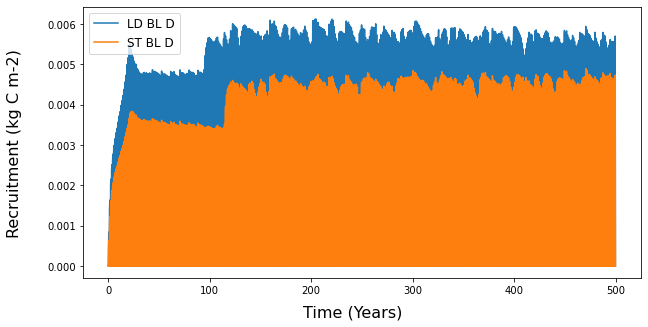

In [26]:
recruit = fates_best.FATES_RECRUITMENT_PF

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(10,5))


axs.plot(time, recruit.isel(fates_levpft=0),label = 'LD BL D')  
axs.plot(time, recruit.isel(fates_levpft=1), label = 'ST BL D')      
axs.legend(prop={'size':12})

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Recruitment (kg C m-2)', fontsize=16)

In [27]:
# This should be initial density - 
init_density = fates.FATES_RECRUITMENT_PF.sel(time=slice("0090-01-01", "0100-01-01")).mean(dim='time')
init_density

<xarray.DataArray 'FATES_RECRUITMENT_PF' (fates_levpft: 2, lndgrid: 1)>
array([[0.00260754],
       [0.00180959]], dtype=float32)
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2
Dimensions without coordinates: lndgrid

### SOIL C

In [ ]:
soilc = fates.SOILC

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, soilc, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'Soil Carbon', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    



In [ ]:
SOIL1C_vr = fates.SOIL1C_vr

In [ ]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, SOIL1C_vr.isel(levdcmp=0), label = decomp_bins.values[0])    

for i in range(1,15) :
    f1ax0.plot(time, SOIL1C_vr.isel(levdcmp=i), label=decomp_bins.values[i])


f1ax0.set_title(r'Soil Carbon 1', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.legend(title = 'soil levels (m)')

In [ ]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, fates.SOIL2C_vr.isel(levdcmp=0), label = decomp_bins.values[0])    

for i in range(1,15) :
    f1ax0.plot(time, fates.SOIL2C_vr.isel(levdcmp=i), label=decomp_bins.values[i])


f1ax0.set_title(r'Soil Carbon 2', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.legend(title = 'soil levels (m)')

In [ ]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, fates.SOIL3C_vr.isel(levdcmp=0), label = decomp_bins.values[0])    

for i in range(1,15) :
    f1ax0.plot(time, fates.SOIL3C_vr.isel(levdcmp=i), label=decomp_bins.values[i])


f1ax0.set_title(r'Soil Carbon 3', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
f1ax0.legend(title = 'soil levels (m)')

In [ ]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, fates.LITTERC)    

f1ax0.set_title(r'Litter C', fontsize = 19)
f1ax0.set_ylabel(r'Litter C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
